# Análisis Exploratorio de Datos (EDA) — Dataset QoS WiFi
## Proyecto de Tesis: Sistema inteligente para la detección y predicción de degradación de conectividad WiFi
**Autor:** Juan Vásquez  
**Universidad:** UDLA — Maestría en Inteligencia Artificial Aplicada  
**Fecha:** Marzo 2026

### Descripción
Este notebook realiza la exploración, limpieza y preparación del dataset de métricas QoS
recolectadas con la Raspberry Pi Zero 2W. El objetivo es preparar los datos para el
entrenamiento del modelo predictivo basado en Random Forest.

In [54]:
#importación de librerías necesarias 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## 1. Carga y unión del dataset

Se cargan los archivos CSV recolectados en distintas sesiones de medición 
y se unifican en un solo DataFrame ordenado cronológicamente por timestamp.

In [55]:
#Se concatenan los conjuntos de datos para unirlos en uno solo y poderlos ordernar
df = pd.read_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datasets\dataset_qos_normal1.csv")
df1 = pd.read_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datasets\dataset_qos_version_Final.csv")
df2 = pd.read_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datasets\dataset_filtrado.csv")
#df3 = pd.read_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datasets\dataset_qos_simulado_final.csv")
#df4 = pd.read_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datasets\dataset_qos_simulado_final_V2.csv")
df5 = pd.read_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datos\dataset_simulado_2026-04-20.csv")
df6 = pd.read_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datos\dataset_simulado_2026-04-21.csv")
df7 = pd.read_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datos\dataset_simulado_2026-04-22.csv")
df_unido = pd.concat([df,df1,df2,df5,df6,df7], ignore_index= True)
#df_unido = pd.concat([df,df1,df2,df3,df4,df5], ignore_index= True)
df_ordenado = df_unido.sort_values("timestamp").reset_index(drop=True)
print(df_ordenado.value_counts("etiqueta_conectividad"))

etiqueta_conectividad
normal       5348
degradada     996
critica       976
Name: count, dtype: int64


## 2. Inspección inicial del dataset
### 2.1 Dimensiones del dataset
Se verifica el número total de filas y columnas del dataset unificado.

In [56]:
#Revisar cuantas filas y columnas tiene el dataset
print(df_ordenado.shape)


(7320, 11)


### 2.2 Estructura y estadísticas descriptivas
Se revisa la estructura del dataset, tipos de datos y estadísticas básicas de cada variable.

In [57]:
#Revisar de forma resumida cual es el contenido del conjunto de datos
print(df_ordenado.head())
print(df_ordenado.info())
print(df_ordenado.describe())

             timestamp  latencia_rtt_ms  jitter_ms  perdida_paquetes_pct  \
0  2026-03-16 00:00:01           18.111      0.766                   0.0   
1  2026-03-16 00:00:31           17.749      0.208                   0.0   
2  2026-03-16 00:01:01           17.853      0.500                   0.0   
3  2026-03-16 00:01:31           17.704      0.190                   0.0   
4  2026-03-16 00:02:01           18.088      0.662                   0.0   

   throughput_descarga_mbps  estado_latencia  estado_jitter  estado_perdida  \
0                    45.608                0              0               0   
1                    45.189                0              0               0   
2                    45.713                0              0               0   
3                    44.874                0              0               0   
4                    44.350                0              0               0   

   estado_throughput  num_umbrales_superados etiqueta_conectividad  

### 2.3 Conversión de timestamp
Se convierte la columna timestamp de tipo string a datetime para permitir
el análisis de series temporales en etapas posteriores.

In [58]:
#se cambia el tipo de dato string a datetime para trabajar con series temporales
df_ordenado["timestamp"] = pd.to_datetime(df_ordenado["timestamp"])

### 2.4 Verificación de valores nulos
Se identifican las columnas con valores faltantes para determinar
la estrategia de imputación más adecuada.

In [59]:
print(df_ordenado.isnull().sum())

timestamp                    1
latencia_rtt_ms             10
jitter_ms                   10
perdida_paquetes_pct         0
throughput_descarga_mbps    11
estado_latencia              0
estado_jitter                0
estado_perdida               0
estado_throughput            0
num_umbrales_superados       0
etiqueta_conectividad        0
dtype: int64


### 2.5 Tratamiento con valores faltantes
Se detectaron valores nulos en latencia_rtt_ms (10), jitter_ms (10) y
throughput_descarga_mbps (41), correspondientes a timeouts de ping y
sesiones sin servidor iperf3 activo respectivamente.
Así que se dropean esos valores para poder limpiar el dataset.



In [60]:
#Etiquetas con valores faltantes son: latencia_rtt_ms, jitter_ms, throughput_descarga_mbps
#Se limpian los datos usando dropna para eliminar todos los valores nulos
#f_limpio = df_ordenado.copy()
df_limpio = df_ordenado.dropna().reset_index(drop=True)
print(df_limpio.shape)


(7308, 11)


### 2.6 Verificación post-imputación
Se confirma que no quedan valores nulos en el dataset después de la imputación.

In [61]:
print(df_limpio.isnull().sum())

timestamp                   0
latencia_rtt_ms             0
jitter_ms                   0
perdida_paquetes_pct        0
throughput_descarga_mbps    0
estado_latencia             0
estado_jitter               0
estado_perdida              0
estado_throughput           0
num_umbrales_superados      0
etiqueta_conectividad       0
dtype: int64


## 3. Distribución de etiquetas de conectividad

Se analiza la distribución de las tres clases objetivo del dataset: 
normal, degradada y crítica.

etiqueta_conectividad
normal       5346
degradada     986
critica       976
Name: count, dtype: int64


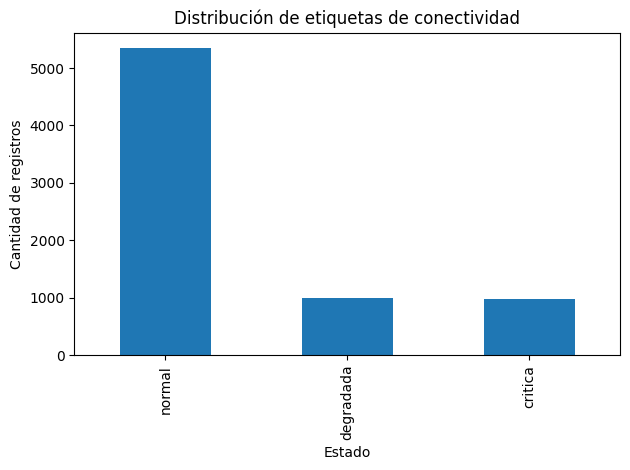

In [62]:
df_contar_etiquetas = df_limpio["etiqueta_conectividad"].value_counts()
print(df_contar_etiquetas)

df_contar_etiquetas.plot(kind ="bar")
plt.title("Distribución de etiquetas de conectividad")
plt.xlabel("Estado")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

El dataset presenta desbalance de clases con predominio de la clase normal (74.7%), 
seguida de degradada (17.4%) y crítica (7.9%). Este desbalance será tratado en la 
etapa de preparación para el entrenamiento mediante técnicas de balanceo de clases.

## 4. Distribución de métricas QoS por estado de conectividad

Se visualiza la distribución de cada una de las 4 métricas diferenciando 
por estado de conectividad para evaluar el poder discriminante de cada variable.

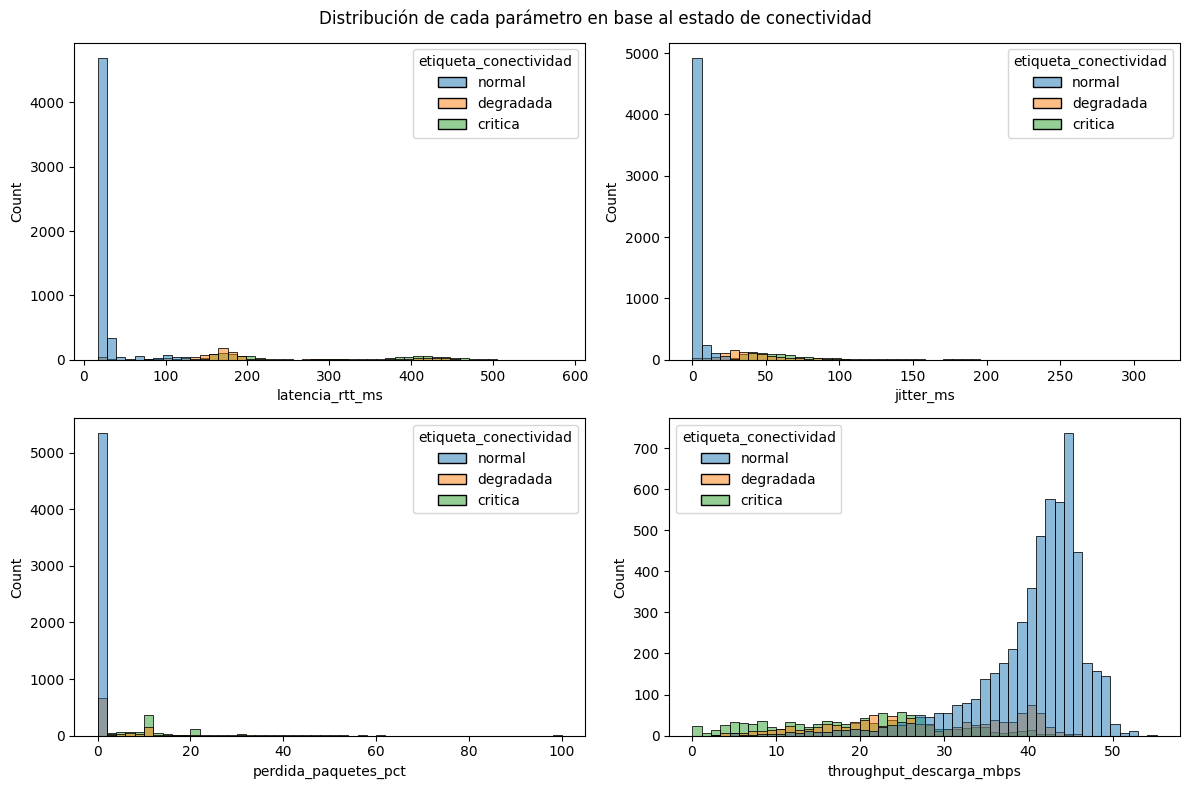

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(data=df_ordenado, x="latencia_rtt_ms", hue="etiqueta_conectividad", bins=50, ax=axes[0,0])
sns.histplot(data=df_ordenado, x="jitter_ms", hue="etiqueta_conectividad", bins=50, ax=axes[0,1])
sns.histplot(data=df_ordenado, x="perdida_paquetes_pct", hue="etiqueta_conectividad", bins=50, ax=axes[1,0])
sns.histplot(data=df_ordenado, x="throughput_descarga_mbps", hue="etiqueta_conectividad", bins=50, ax=axes[1,1])
fig.suptitle("Distribución de cada parámetro en base al estado de conectividad")
plt.tight_layout()
plt.show()

Los histogramas revelan patrones de separación entre clases:

- **Latencia RTT**: Separación clara entre las tres clases — normal (~18-20 ms), 
degradada (~170 ms) y crítica (~400-500 ms). Alta capacidad discriminante.
- **Jitter**: Comportamiento similar a la latencia con cierto solapamiento entre 
degradada y crítica en rangos intermedios.
- **Pérdida de paquetes**: Normal concentrada en 0%, con solapamiento entre 
degradada y crítica en valores más altos.
- **Throughput**: Las tres clases se concentran en el mismo rango (~35-45 Mbps), 
confirmando que esta métrica no es discriminante debido a las limitaciones del 
adaptador WiFi de la Raspberry Pi Zero 2W.

## 5. Matriz de correlación entre métricas QoS

Se analiza la correlación entre las 4 métricas para identificar relaciones
entre variables y determinar cuáles aportan información independiente al modelo.
Una correlación alta entre dos variables indica redundancia de información.

Index(['timestamp', 'latencia_rtt_ms', 'jitter_ms', 'perdida_paquetes_pct',
       'throughput_descarga_mbps', 'estado_latencia', 'estado_jitter',
       'estado_perdida', 'estado_throughput', 'num_umbrales_superados',
       'etiqueta_conectividad'],
      dtype='object')
                          latencia_rtt_ms  jitter_ms  perdida_paquetes_pct  \
latencia_rtt_ms                  1.000000   0.865762              0.648376   
jitter_ms                        0.865762   1.000000              0.732012   
perdida_paquetes_pct             0.648376   0.732012              1.000000   
throughput_descarga_mbps        -0.724301  -0.717646             -0.596242   

                          throughput_descarga_mbps  
latencia_rtt_ms                          -0.724301  
jitter_ms                                -0.717646  
perdida_paquetes_pct                     -0.596242  
throughput_descarga_mbps                  1.000000  


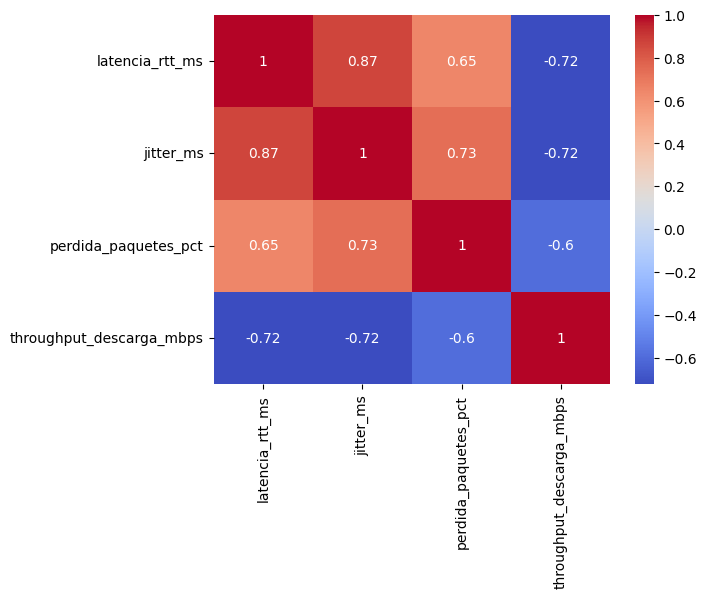

In [64]:
#se seleccionan las 4 métricas dentro de una lista
print(df_limpio.columns)
metricas = df_limpio[["latencia_rtt_ms","jitter_ms","perdida_paquetes_pct", "throughput_descarga_mbps"]]
correlacion = metricas.corr()
print(correlacion)
sns.heatmap(data= correlacion, cmap="coolwarm", annot=True)
plt.show()



### Análisis de correlación

El heatmap revela las siguientes relaciones entre métricas:

- **Latencia RTT y Jitter (0.85)**: Correlación muy alta, ambas métricas se comportan 
de forma casi idéntica ya que tc netem las afecta simultáneamente. Esto sugiere cierta 
redundancia de información entre estas dos variables.
- **Latencia RTT y Throughput (-0.73)**: Correlación negativa fuerte, confirma que 
a mayor latencia menor throughput efectivo, consistente con el comportamiento de TCP.
- **Jitter y Throughput (-0.65)**: Correlación negativa moderada, mismo patrón que 
la latencia.
- **Pérdida de paquetes y Throughput (-0.32)**: Correlación negativa débil, lo que 
refuerza la observación de que el throughput no es una métrica discriminante en este 
dataset debido a las limitaciones del adaptador WiFi de la Raspberry Pi Zero 2W.

A pesar de la correlación entre latencia y jitter, se mantienen ambas variables en 
el modelo ya que cada una captura un aspecto distinto del comportamiento de la red.

## 6. Serie temporal de métricas QoS

Se visualiza la evolución de las 4 métricas a lo largo del tiempo para
confirmar que las transiciones graduales de degradación fueron capturadas
correctamente durante la simulación con tc netem.

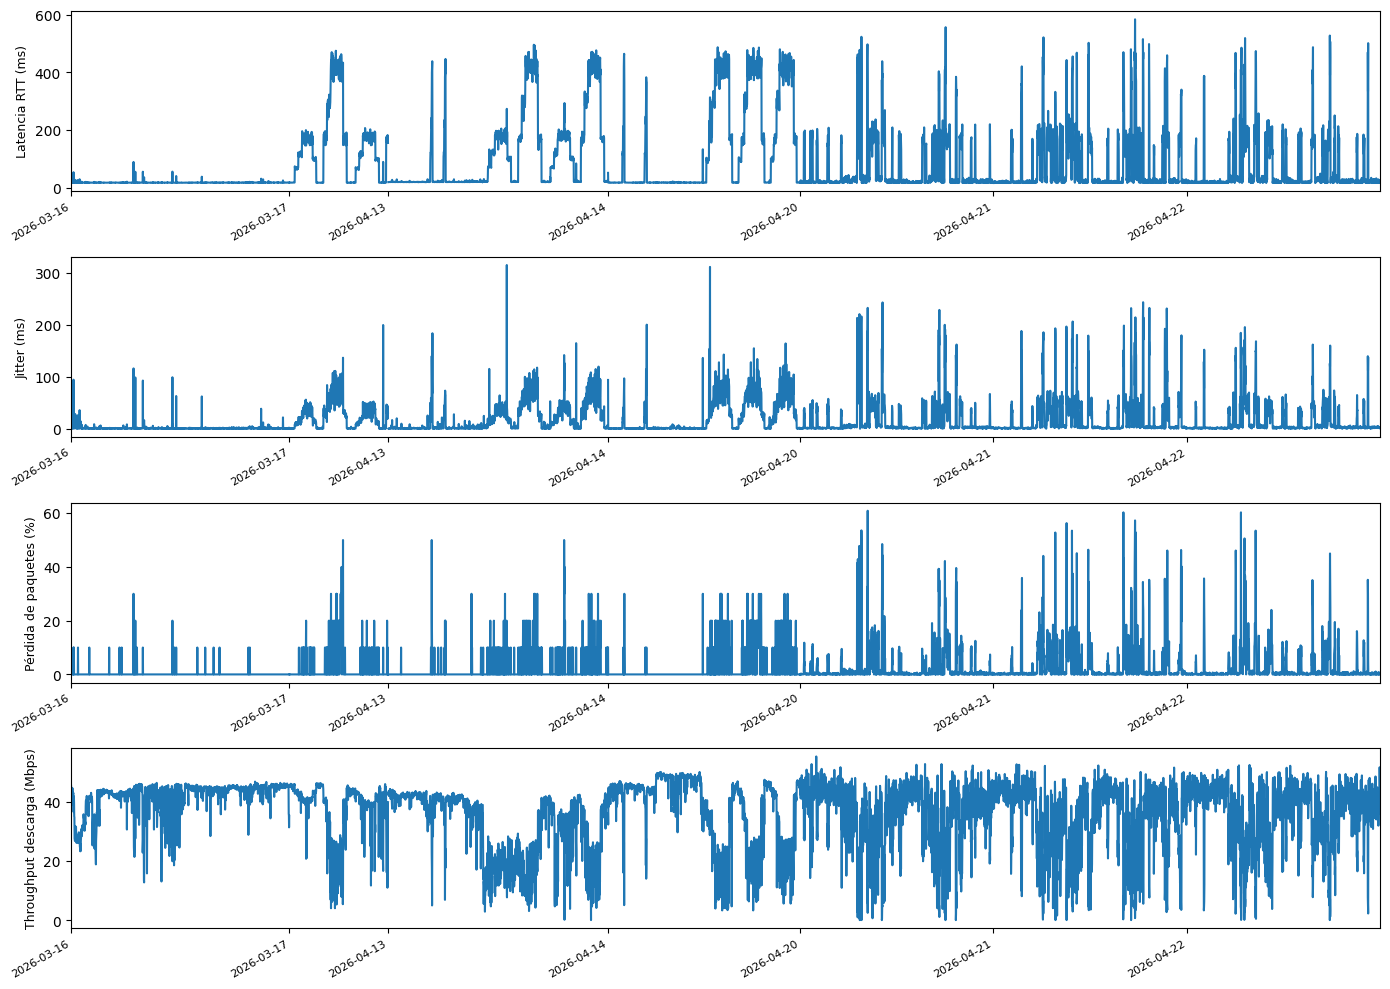

In [65]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
df_plot = df_limpio.copy().reset_index(drop=True)

# Detectar gaps > 5 min y poner NaN para no conectar sesiones
gaps = df_plot["timestamp"].diff() > pd.Timedelta("5min")
df_plot.loc[gaps, ["latencia_rtt_ms", "jitter_ms",
                   "perdida_paquetes_pct", "throughput_descarga_mbps"]] = None

idx = df_plot.index  # eje X por posición, no por tiempo

metricas = ["latencia_rtt_ms", "jitter_ms",
            "perdida_paquetes_pct", "throughput_descarga_mbps"]
titulos  = ["Latencia RTT (ms)", "Jitter (ms)",
            "Pérdida de paquetes (%)", "Throughput descarga (Mbps)"]

for ax, metrica, titulo in zip(axes, metricas, titulos):
    ax.plot(idx, df_plot[metrica])
    ax.set_ylabel(titulo, fontsize=9)
    ax.set_xlim(idx[0], idx[-1])

# Etiquetas del eje X: mostrar solo el inicio de cada fecha distinta
fechas_cambio = df_plot[df_plot["timestamp"].dt.date !=
                        df_plot["timestamp"].dt.date.shift()].index
fechas_labels = df_plot.loc[fechas_cambio, "timestamp"].dt.strftime("%Y-%m-%d")

for ax in axes:
    ax.set_xticks(fechas_cambio)
    ax.set_xticklabels(fechas_labels, rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

### Análisis de la serie temporal

La serie temporal confirma la estructura del dataset a lo largo de 4 sesiones 
de medición entre el 15 y 19 de marzo de 2026:

- **15-16 de marzo**: Condiciones normales con degradaciones esporádicas naturales 
de corta duración, reflejando el comportamiento real de la red universitaria.
- **17-19 de marzo**: Sesiones de simulación con tc netem donde se observan 
claramente los ciclos de degradación gradual — latencia alcanzando 400-500 ms, 
jitter elevado, pérdida de paquetes sostenida y caídas del throughput.

Las transiciones graduales entre estados son visibles en todas las métricas, 
confirmando que el dataset contiene los patrones temporales necesarios para 
el entrenamiento del modelo predictivo.

In [66]:
#Exporta el dataset limpio 
df_limpio.to_csv(r"C:\Users\juanj\Desktop\Maestría\Tesis\Datasets\dataset_qos_limpio.csv", index=False)